# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: ZIYAN WANG
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [17]:
#Import packages
import pandas as pd
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from calendar import month_abbr
import time

#Set Seaborn theme
sns.set_theme(style="darkgrid", context="notebook")

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [18]:
# 2.1 Retrieve the website and parse it using BeautifulSoup
url = "https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025"

response = requests.get(url, timeout=30)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")

print(webpage.title.get_text(strip=True))


DWR :: Local Water Supply Planning


### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [19]:
# 2.2 Scrape the data into variables
contact_table = webpage.select_one('a[name="contact"]').find_next("table")
water_system = contact_table.select_one(
    "tr:nth-of-type(1) td:nth-of-type(2)"
).get_text(strip=True)
contact_person = contact_table.select_one(
    "tr:nth-of-type(4) td:nth-of-type(2)"
).get_text(strip=True)
ownership = contact_table.select_one(
    "tr:nth-of-type(2) td:nth-of-type(4)"
).get_text(strip=True)

monthly_table = webpage.select_one(
    'a[name="monthly-withdrawal"]'
).find_next("table")
max_day_nodes = monthly_table.select(
    "tr td:nth-of-type(2), tr td:nth-of-type(4), tr td:nth-of-type(6)"
)
max_day_use = [node.get_text(strip=True) for node in max_day_nodes]

print(water_system)
print(contact_person)
print(ownership)
print(max_day_use)

Durham
Kieu Tran
Municipality
['40.2400', '37.3800', '37.9100', '33.8100', '36.8400', '36.9000', '36.5300', '38.0400', '33.8000', '37.9500', '35.2000', '32.2000']


### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [20]:
# 2.3 Construct the dataframe from scraped data
month_order = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]

df_durham_2025 = pd.DataFrame({
    "Month": month_order,
    "Year": 2025,
    "Water_System": water_system,
    "Contact_Person": contact_person,
    "Ownership": ownership,
    "Max_Day_Use_mgd": pd.to_numeric(max_day_use),
})

df_durham_2025["Date"] = pd.to_datetime({
    "year": df_durham_2025["Year"],
    "month": df_durham_2025["Month"],
    "day": 1,
})
df_durham_2025 = df_durham_2025.sort_values(
    ["Year", "Month"]
).reset_index(drop=True)
df_durham_2025


,Month,Year,Water_System,Contact_Person,Ownership,Max_Day_Use_mgd,Date
0,1,2025,Durham,Kieu Tran,Municipality,40.24,2025-01-01
1,2,2025,Durham,Kieu Tran,Municipality,33.81,2025-02-01
2,3,2025,Durham,Kieu Tran,Municipality,36.53,2025-03-01
3,4,2025,Durham,Kieu Tran,Municipality,37.95,2025-04-01
4,5,2025,Durham,Kieu Tran,Municipality,37.38,2025-05-01
5,6,2025,Durham,Kieu Tran,Municipality,36.84,2025-06-01
6,7,2025,Durham,Kieu Tran,Municipality,38.04,2025-07-01
7,8,2025,Durham,Kieu Tran,Municipality,35.20,2025-08-01
8,9,2025,Durham,Kieu Tran,Municipality,37.91,2025-09-01
9,10,2025,Durham,Kieu Tran,Municipality,36.90,2025-10-01


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2024
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

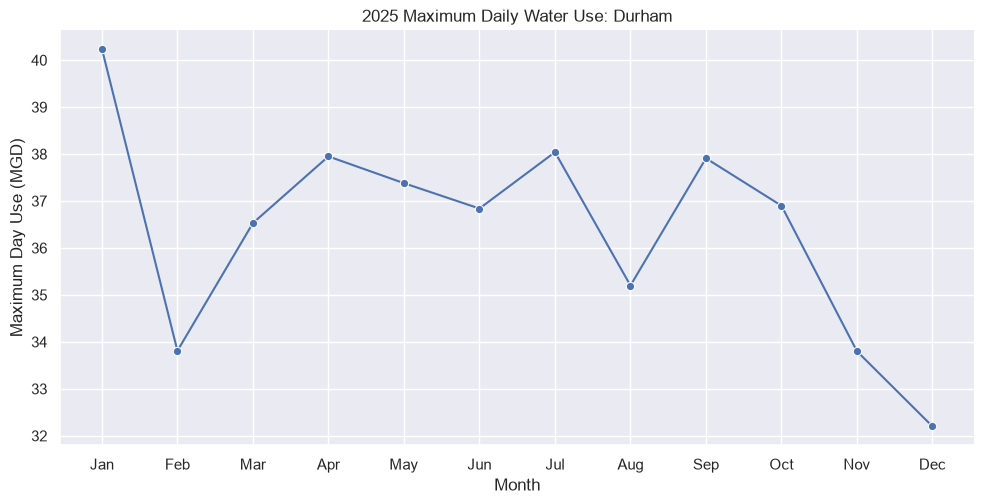

In [21]:
# 2.4 Plot the data
g = sns.relplot(
    data=df_durham_2025,
    x="Month",
    y="Max_Day_Use_mgd",
    kind="line",
    marker="o",
    aspect=2,
)
g.set(
    title=f"2025 Maximum Daily Water Use: {water_system}",
    xlabel="Month",
    ylabel="Maximum Day Use (MGD)",
    xticks=range(1, 13),
    xticklabels=list(month_abbr)[1:],
);

## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [22]:
# 3.1 Create a scraping function
def scrape_lwsp(PWSID, year):
    """Scrape monthly maximum-day water use for one system and year."""
    #Construct the URL and fetch the web page
    url = (
        "https://www.ncwater.org/WUDC/app/LWSP/report.php"
        f"?pwsid={PWSID}&year={year}"
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    the_website = BeautifulSoup(response.text, "html.parser")

    #Extract the system information using CSS selectors
    contact_table = the_website.select_one(
        'a[name="contact"]'
    ).find_next("table")
    water_system = contact_table.select_one(
        "tr:nth-of-type(1) td:nth-of-type(2)"
    ).get_text(strip=True)
    contact_person = contact_table.select_one(
        "tr:nth-of-type(4) td:nth-of-type(2)"
    ).get_text(strip=True)
    ownership = contact_table.select_one(
        "tr:nth-of-type(2) td:nth-of-type(4)"
    ).get_text(strip=True)

    #Extract the 12 maximum-day-use values
    monthly_table = the_website.select_one(
        'a[name="monthly-withdrawal"]'
    ).find_next("table")
    max_day_nodes = monthly_table.select(
        "tr td:nth-of-type(2), tr td:nth-of-type(4), "
        "tr td:nth-of-type(6)"
    )
    max_day_use = [x.get_text(strip=True) for x in max_day_nodes]
    if len(max_day_use) != 12:
        raise ValueError(
            f"Expected 12 monthly values for {PWSID} in {year}; "
            f"found {len(max_day_use)}."
        )

    #Wrangle the scraped values into a dataframe
    month_order = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]
    df = pd.DataFrame({
        "PWSID": PWSID,
        "Month": month_order,
        "Year": year,
        "Water_System": water_system,
        "Contact_Person": contact_person,
        "Ownership": ownership,
        "Max_Day_Use_mgd": pd.to_numeric(max_day_use),
    })
    df["Date"] = pd.to_datetime({
        "year": df["Year"],
        "month": df["Month"],
        "day": 1,
    })
    df = df.sort_values(["Year", "Month"]).reset_index(drop=True)

    #Pause briefly before another request, as in the M6 workflow
    time.sleep(0.25)
    return df


### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [23]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure
df_durham_2020 = scrape_lwsp("03-32-010", 2020)
df_durham_2020.info()
df_durham_2020

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   PWSID            12 non-null     str           
 1   Month            12 non-null     int64         
 2   Year             12 non-null     int64         
 3   Water_System     12 non-null     str           
 4   Contact_Person   12 non-null     str           
 5   Ownership        12 non-null     str           
 6   Max_Day_Use_mgd  12 non-null     float64       
 7   Date             12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 900.0 bytes


,PWSID,Month,Year,Water_System,Contact_Person,Ownership,Max_Day_Use_mgd,Date
0,03-32-010,1,2020,Durham,Kieu Tran,Municipality,36.01,2020-01-01
1,03-32-010,2,2020,Durham,Kieu Tran,Municipality,32.05,2020-02-01
2,03-32-010,3,2020,Durham,Kieu Tran,Municipality,37.29,2020-03-01
3,03-32-010,4,2020,Durham,Kieu Tran,Municipality,32.37,2020-04-01
4,03-32-010,5,2020,Durham,Kieu Tran,Municipality,36.98,2020-05-01
5,03-32-010,6,2020,Durham,Kieu Tran,Municipality,40.61,2020-06-01
6,03-32-010,7,2020,Durham,Kieu Tran,Municipality,43.63,2020-07-01
7,03-32-010,8,2020,Durham,Kieu Tran,Municipality,41.93,2020-08-01
8,03-32-010,9,2020,Durham,Kieu Tran,Municipality,41.69,2020-09-01
9,03-32-010,10,2020,Durham,Kieu Tran,Municipality,40.56,2020-10-01


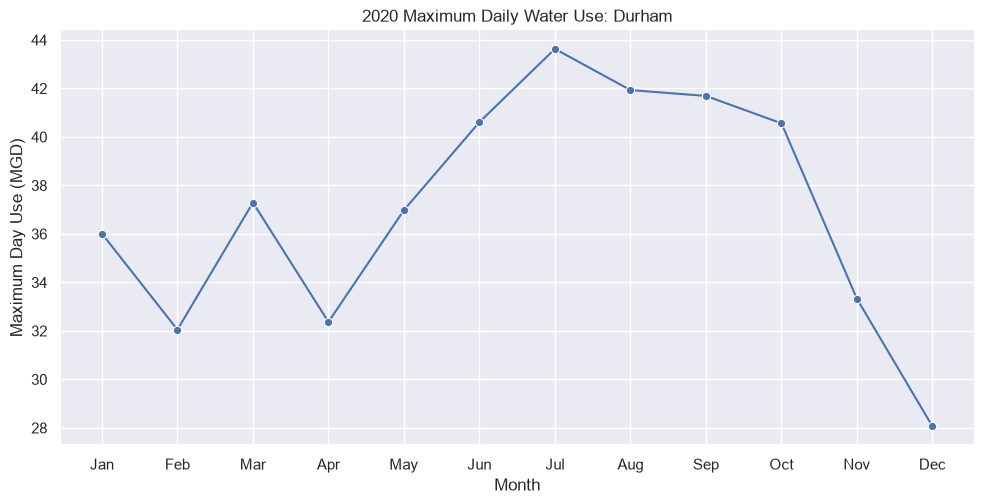

In [24]:
# 3.2.2 Plot the data
g = sns.relplot(
    data=df_durham_2020,
    x="Month",
    y="Max_Day_Use_mgd",
    kind="line",
    marker="o",
    aspect=2,
)
g.set(
    title="2020 Maximum Daily Water Use: Durham",
    xlabel="Month",
    ylabel="Maximum Day Use (MGD)",
    xticks=range(1, 13),
    xticklabels=list(month_abbr)[1:],
);

### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [25]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020
df_cary_2020 = scrape_lwsp("03-92-020", 2020)
df_cary_2020


,PWSID,Month,Year,Water_System,Contact_Person,Ownership,Max_Day_Use_mgd,Date
0,03-92-020,1,2020,Cary,Jamie Revels,Municipality,21.95,2020-01-01
1,03-92-020,2,2020,Cary,Jamie Revels,Municipality,17.70,2020-02-01
2,03-92-020,3,2020,Cary,Jamie Revels,Municipality,20.56,2020-03-01
3,03-92-020,4,2020,Cary,Jamie Revels,Municipality,19.32,2020-04-01
4,03-92-020,5,2020,Cary,Jamie Revels,Municipality,23.22,2020-05-01
5,03-92-020,6,2020,Cary,Jamie Revels,Municipality,26.19,2020-06-01
6,03-92-020,7,2020,Cary,Jamie Revels,Municipality,28.01,2020-07-01
7,03-92-020,8,2020,Cary,Jamie Revels,Municipality,25.40,2020-08-01
8,03-92-020,9,2020,Cary,Jamie Revels,Municipality,25.49,2020-09-01
9,03-92-020,10,2020,Cary,Jamie Revels,Municipality,23.60,2020-10-01


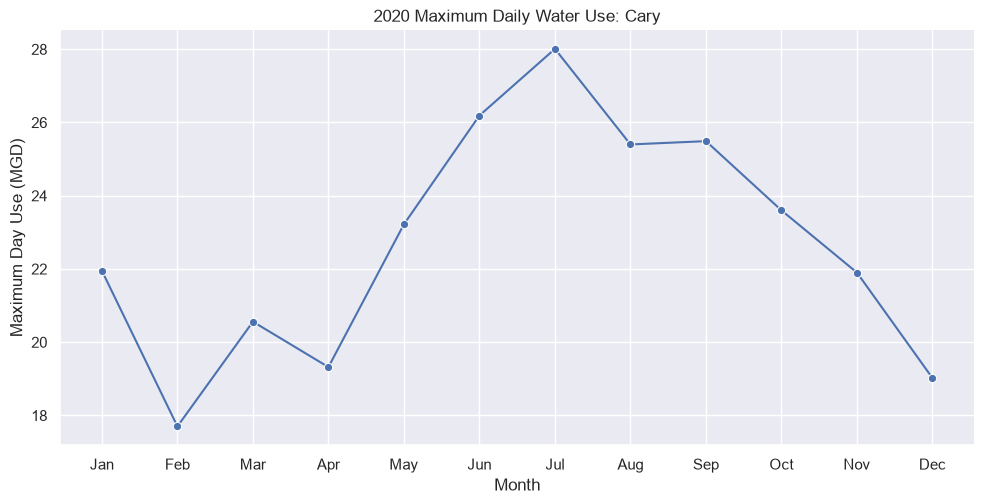

In [26]:
# 3.3.2 Plot the Cary data
g = sns.relplot(
    data=df_cary_2020,
    x="Month",
    y="Max_Day_Use_mgd",
    kind="line",
    marker="o",
    aspect=2,
)
g.set(
    title="2020 Maximum Daily Water Use: Cary",
    xlabel="Month",
    ylabel="Maximum Day Use (MGD)",
    xticks=range(1, 13),
    xticklabels=list(month_abbr)[1:],
);

### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [27]:
# 3.4.1 Generate a list of the dataframes
the_years = range(2020, 2026)
the_dfs = [scrape_lwsp("03-92-020", year) for year in the_years]

# 3.4.2 Combine them into a single dataframe
df_cary_2020_2025 = pd.concat(the_dfs, ignore_index=True)
df_cary_2020_2025

,PWSID,Month,Year,Water_System,Contact_Person,Ownership,Max_Day_Use_mgd,Date
0,03-92-020,1,2020,Cary,Jamie Revels,Municipality,21.95,2020-01-01
1,03-92-020,2,2020,Cary,Jamie Revels,Municipality,17.70,2020-02-01
2,03-92-020,3,2020,Cary,Jamie Revels,Municipality,20.56,2020-03-01
3,03-92-020,4,2020,Cary,Jamie Revels,Municipality,19.32,2020-04-01
4,03-92-020,5,2020,Cary,Jamie Revels,Municipality,23.22,2020-05-01
...,...,...,...,...,...,...,...,...
67,03-92-020,8,2025,Cary,Jamie Revels,Municipality,26.75,2025-08-01
68,03-92-020,9,2025,Cary,Jamie Revels,Municipality,26.40,2025-09-01
69,03-92-020,10,2025,Cary,Jamie Revels,Municipality,25.72,2025-10-01
70,03-92-020,11,2025,Cary,Jamie Revels,Municipality,22.51,2025-11-01


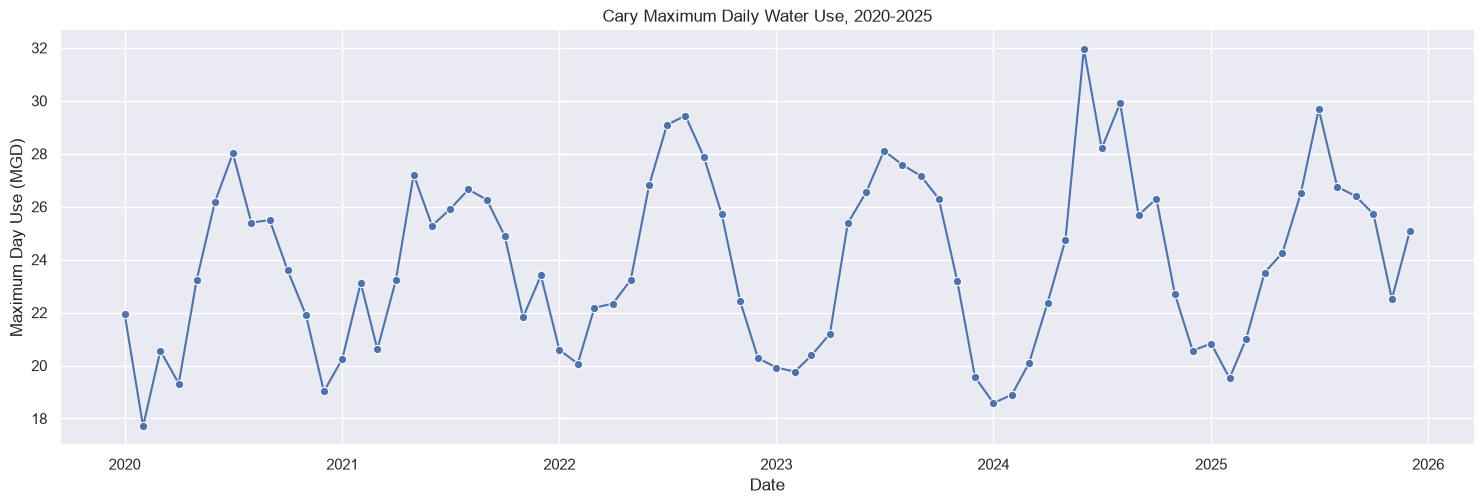

In [28]:
# 3.4.3 Plot
g = sns.relplot(
    data=df_cary_2020_2025,
    x="Date",
    y="Max_Day_Use_mgd",
    kind="line",
    marker="o",
    aspect=3,
)
g.set(
    title="Cary Maximum Daily Water Use, 2020-2025",
    xlabel="Date",
    ylabel="Maximum Day Use (MGD)",
);